In [2]:
import matplotlib.pyplot as plt
import pandas as pd

Nombre de valeurs manquantes dans le jeu de données : 0


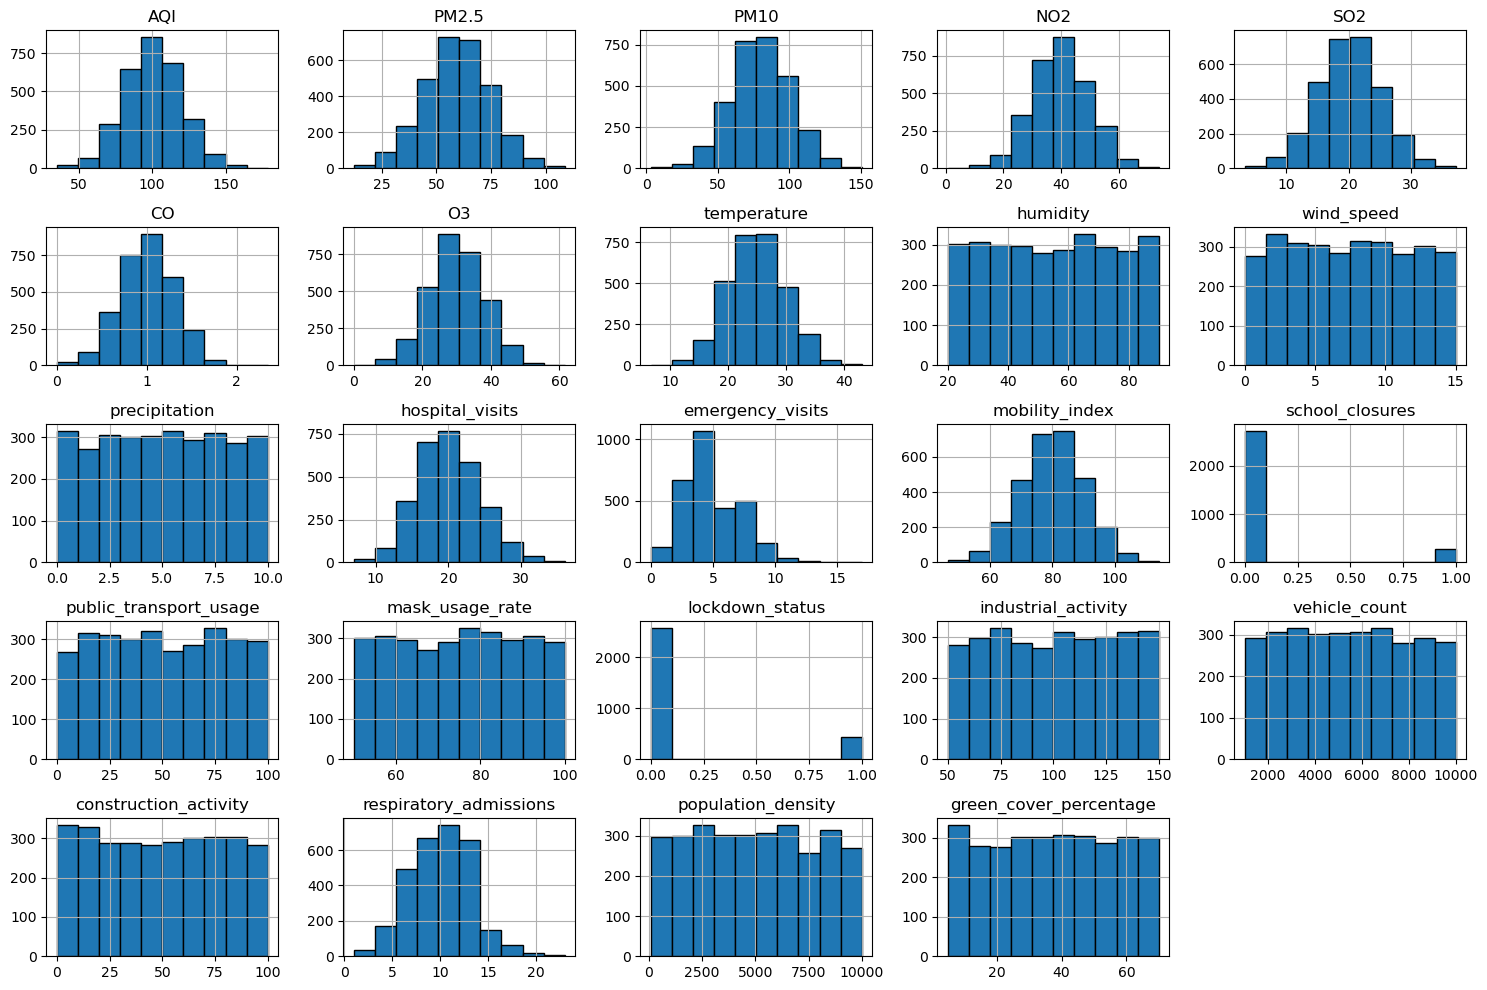

In [5]:
df = pd.read_csv('data/air_quality_health_dataset.csv', encoding='utf-8')

# Vérification des valeurs manquantes
valeurs_manquantes = df.isna().sum().sum()
print("Nombre de valeurs manquantes dans le jeu de données :", valeurs_manquantes)

df.hist(edgecolor="black", figsize=(15, 10))
plt.tight_layout()
plt.show()

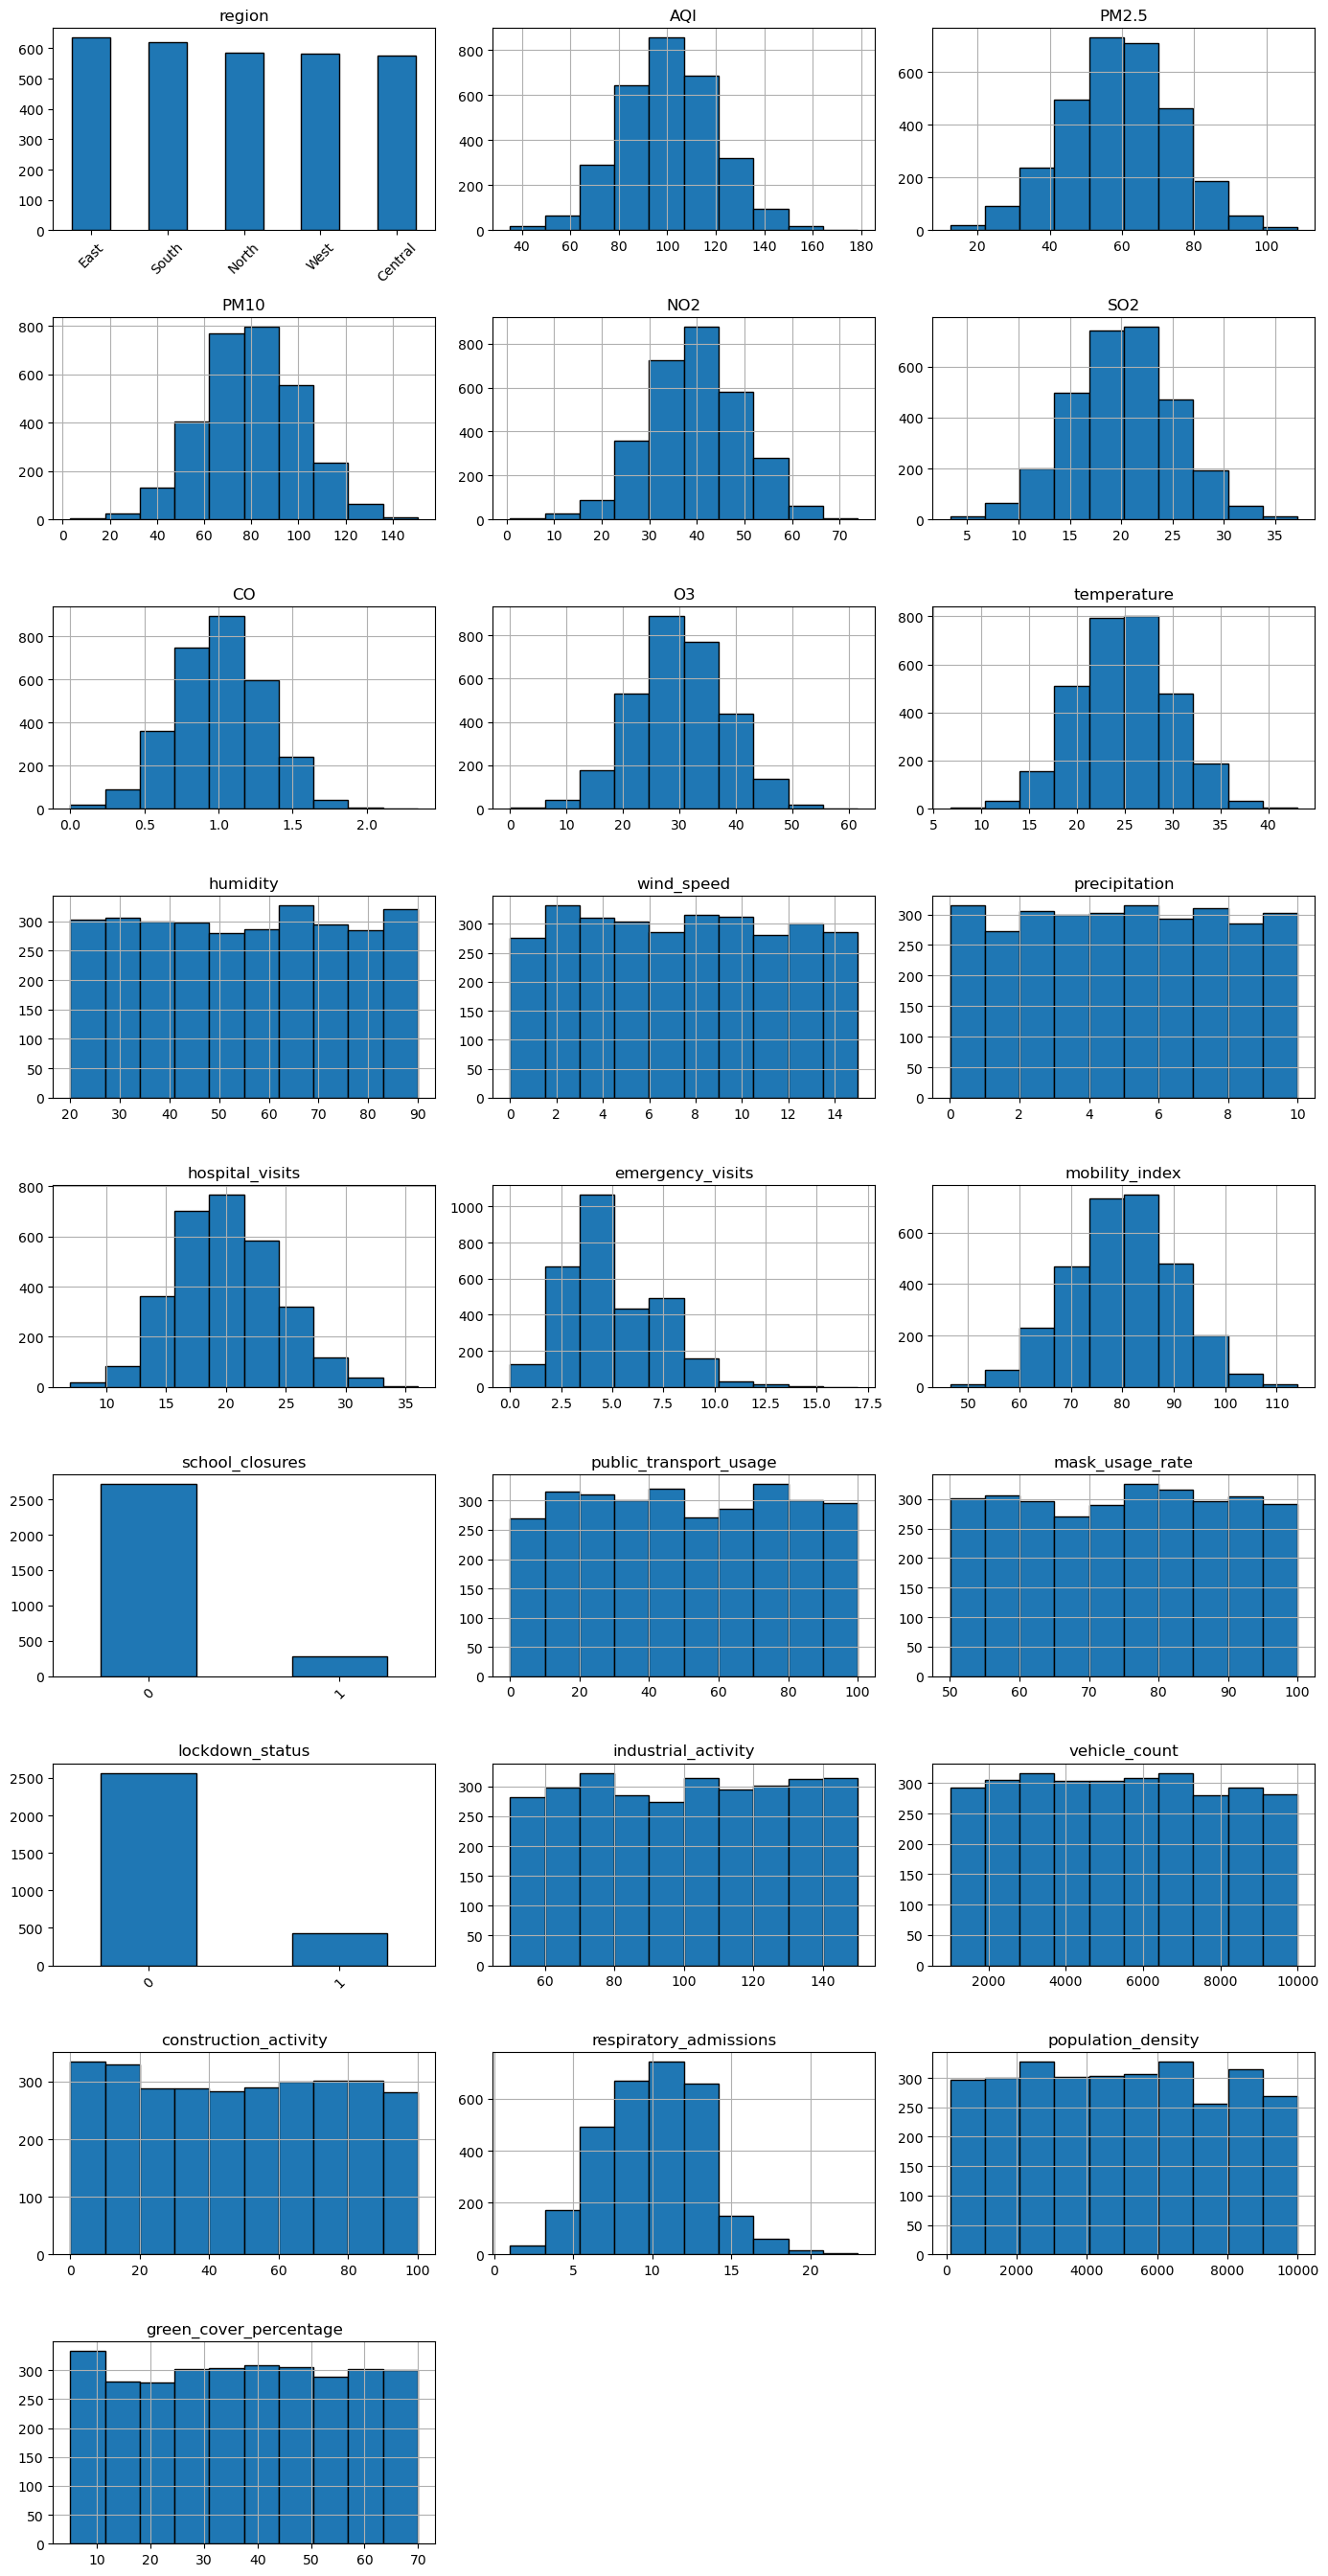

'cat_cols = [\n    c for c in df.columns\n    if c not in date_cols\n    and not pd.api.types.is_datetime64_any_dtype(df[c])\n    and (df[c].dtype == "object" or df[c].nunique() <= 10)\n]\n\nncols = 3\nnrows = math.ceil(len(cat_cols) / ncols)\nfig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), squeeze=False)\naxes = axes.flatten()\n\nfor ax, col in zip(axes, cat_cols):\n    df[col].value_counts().plot(kind=\'bar\', ax=ax, edgecolor=\'black\')\n    ax.set_title(col)\n    ax.set_xlabel(\'\')\n    ax.tick_params(axis=\'x\', rotation=45)\n\nfor ax in axes[len(cat_cols):]:\n    ax.set_visible(False)  # masque les cases vides de la grille\n\nplt.tight_layout()\nplt.show()'

In [11]:
import math

# Colonnes catégorielles : texte, ou numériques avec peu de valeurs distinctes (ex. 0/1)
date_cols = {"date"} #pas d'histogramme par date

plot_cols = [
    col for col in df.columns
    if str(col).lower() not in date_cols
    and not pd.api.types.is_datetime64_any_dtype(df[col])
]

cat_cols = [
    col for col in plot_cols
    if df[col].dtype == "object" or df[col].nunique() <= 10
]

ncols = 3
nrows = math.ceil(len(plot_cols) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14,3 * nrows), squeeze=False)
axes = axes.flatten()

for axis, col in zip(axes, plot_cols):
    if col in cat_cols:
        df[col].value_counts().plot(kind="bar", ax=axis, edgecolor="black")
        axis.tick_params(axis="x", rotation=45)
        axis.set_xlabel("")
    else:
        df[col].hist(ax=axis, edgecolor="black")

    axis.set_title(col)

for axis in axes[len(plot_cols):]:
    axis.set_visible(False)

plt.tight_layout()
plt.show()



"""cat_cols = [
    c for c in df.columns
    if c not in date_cols
    and not pd.api.types.is_datetime64_any_dtype(df[c])
    and (df[c].dtype == "object" or df[c].nunique() <= 10)
]

ncols = 3
nrows = math.ceil(len(cat_cols) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), squeeze=False)
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

for ax in axes[len(cat_cols):]:
    ax.set_visible(False)  # masque les cases vides de la grille

plt.tight_layout()
plt.show()"""

Données relativement équilibrées par régions, mais peu de fermetures d'écoles ou de confinement

                             AQI     PM2.5      PM10       NO2       SO2  \
AQI                     1.000000 -0.009779  0.009245  0.011191 -0.021223   
PM2.5                  -0.009779  1.000000  0.018799 -0.020119 -0.026897   
PM10                    0.009245  0.018799  1.000000 -0.000534  0.028040   
NO2                     0.011191 -0.020119 -0.000534  1.000000 -0.026433   
SO2                    -0.021223 -0.026897  0.028040 -0.026433  1.000000   
CO                     -0.002879  0.015096  0.013447 -0.006825  0.011149   
O3                      0.000786  0.002769  0.003868  0.020560  0.043218   
temperature            -0.032363 -0.003670  0.008380 -0.020529  0.031864   
humidity               -0.002099  0.009473 -0.002981  0.030221  0.017304   
wind_speed              0.004828 -0.022694 -0.043216 -0.005383 -0.016123   
precipitation          -0.019581 -0.024068  0.008139 -0.029446  0.010988   
hospital_visits         0.008556 -0.002590  0.006056  0.000693  0.002246   
emergency_vi

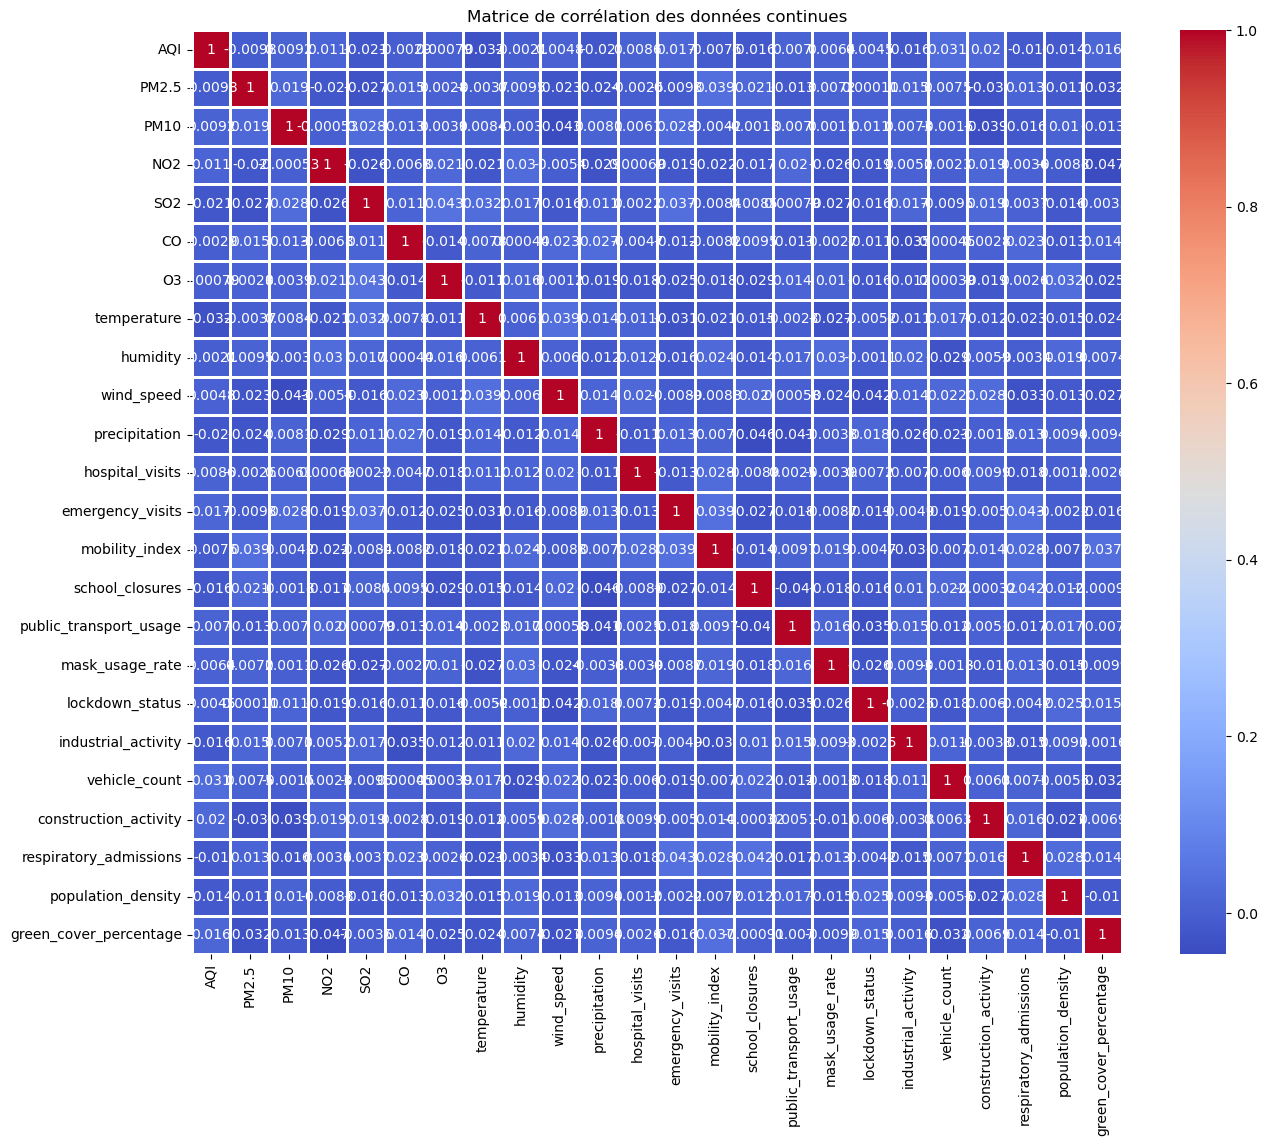

In [13]:
#Matrice de correlation
import seaborn 
numeric_df = df.select_dtypes(include="number")
corr_matrix = numeric_df.corr()

print(corr_matrix)

plt.figure(figsize=(15, 12))
seaborn.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidth=2)
plt.title("Matrice de corrélation des données continues")
plt.show()

Aucune corrélation évidente n'apparait entre les données brutes.